# 1. Limpieza de Datos

In [27]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('data/titanic.csv')

In [29]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
628,629,0,3,"Bostandyeff, Mr. Guentcho",male,26.0,0,0,349224,7.8958,NaN,S
292,293,0,2,"Levy, Mr. Rene Jacques",male,36.0,0,0,SC/Paris 2163,12.8750,D,C
421,422,0,3,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q


In [30]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [31]:
df.info("data/titanic.csv")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


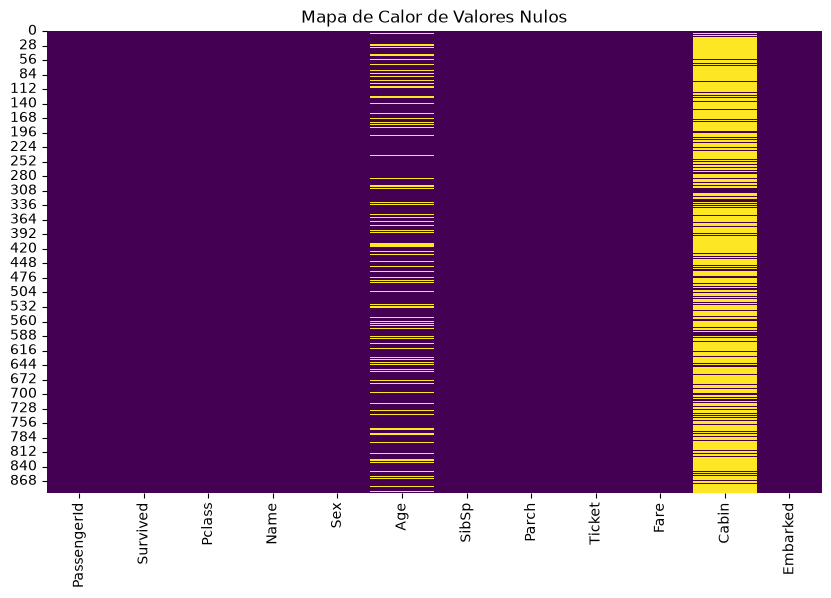

In [32]:
# Suponiendo que tu dataframe se llama 'df'
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('output.png', format='png')

# Mostrar el gráfico
plt.show()

In [33]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


/tmp/ipykernel_5826/2959951133.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


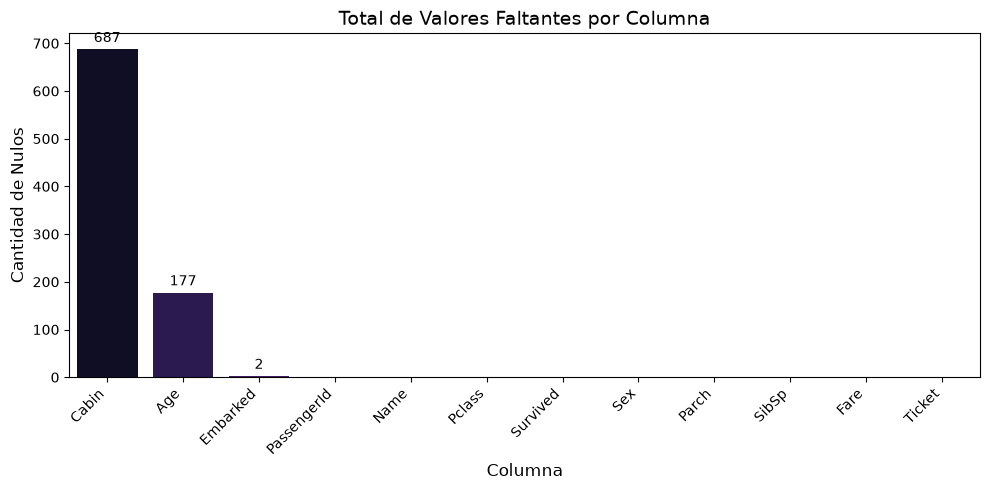

In [35]:
# 1. Calcular la cantidad de valores faltantes por columna
missing_data = df.isnull().sum().reset_index()
missing_data.columns = ['Columna', 'Valores_Faltantes']

# 2. Ordenar las columnas de mayor a menor según los datos faltantes
missing_data = missing_data.sort_values(by='Valores_Faltantes', ascending=False)

# 3. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 5))

# 4. Crear el gráfico de barras con Seaborn
ax = sns.barplot(
    x='Columna', 
    y='Valores_Faltantes', 
    data=missing_data, 
    palette='magma'
)

# 5. Estilizar y añadir etiquetas
plt.title('Total de Valores Faltantes por Columna', fontsize=14)
plt.xlabel('Columna', fontsize=12)
plt.ylabel('Cantidad de Nulos', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir el número exacto de nulos sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Muestra el número solo si hay valores nulos
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [36]:
df.drop('Cabin', axis = 1, inplace = True)

In [39]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])



In [40]:
print("Valores nulos por columna")
print(df.isnull().sum())

Valores nulos por columna
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)

In [43]:
df.to_csv('./data/titanic_clean.csv', index=False)